In [2]:
import pandas as pd
df=pd.read_csv('ecommerce_data.csv')

In [3]:
df.head()

,order_id,order_date,product_id,category,price,quantity,total_amount,region,payment_type
0,ORD1001,2025-01-01,PRD501,Electronics,499.99,1,499.99,North,Card
1,ORD1002,2025-01-01,PRD302,Home Appliances,249.50,2,499.00,West,UPI
2,ORD1003,2025-01-01,PRD784,Fashion,79.99,3,239.97,South,Wallet
3,ORD1004,2025-01-02,PRD129,Books,15.99,4,63.96,East,Card
4,ORD1005,2025-01-02,PRD643,Electronics,1299.00,1,1299.00,North,Card


In [6]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [7]:
daily_metrics = (
    df.groupby("order_date")
      .agg(
          daily_revenue=("total_amount", "sum"),
          daily_orders=("order_id", "nunique")
      )
      .reset_index()
)


In [8]:
daily_metrics["avg_order_value"] = (
    daily_metrics["daily_revenue"] / daily_metrics["daily_orders"]
)


In [9]:
daily_metrics.head()

,order_date,daily_revenue,daily_orders,avg_order_value
0,2025-01-01,1238.96,3,412.986667
1,2025-01-02,1512.91,3,504.303333
2,2025-01-03,1416.49,3,472.163333
3,2025-01-04,639.84,3,213.280000
4,2025-01-05,661.99,3,220.663333


In [60]:
daily_df = (
    df.groupby("order_date")
      .agg(daily_revenue=("total_amount", "sum"))
      .asfreq("D", fill_value=0)   # ensure no missing dates
      .reset_index()
)


In [78]:
y = daily_df["daily_revenue"]

### ACF for raw data

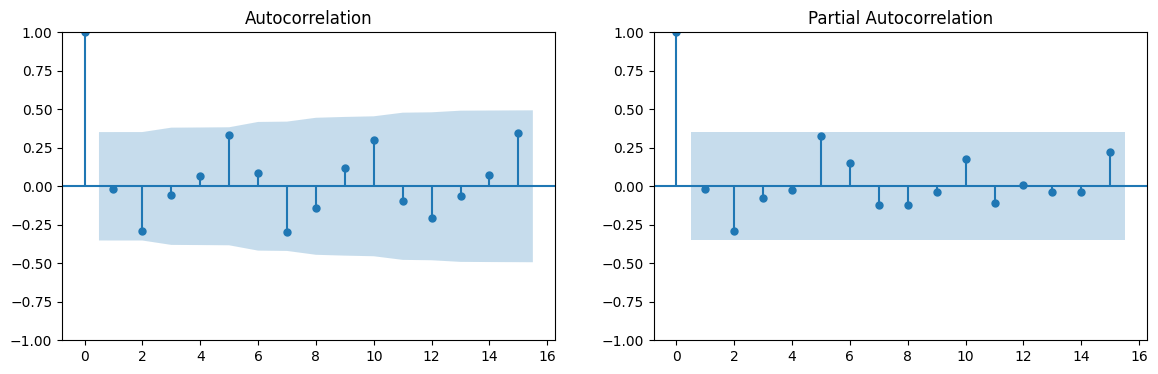

In [79]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,4))

plot_acf(y,  ax=axes[0])
plot_pacf(y,  ax=axes[1])

plt.show()


<Axes: title={'center': 'Daily Revenue'}>

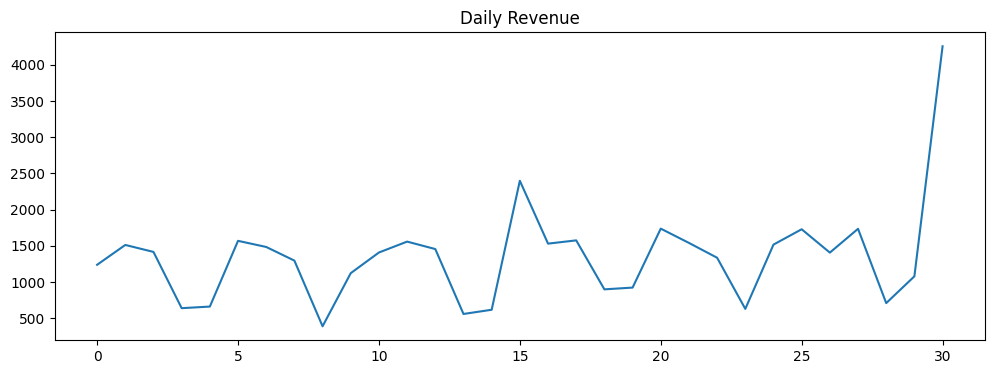

In [13]:
y.plot(figsize=(12,4), title="Daily Revenue")



In [20]:
s=5
d=0

y_seasonal_diff = y.diff(s).dropna()

<Axes: title={'center': 'Daily Revenue'}>

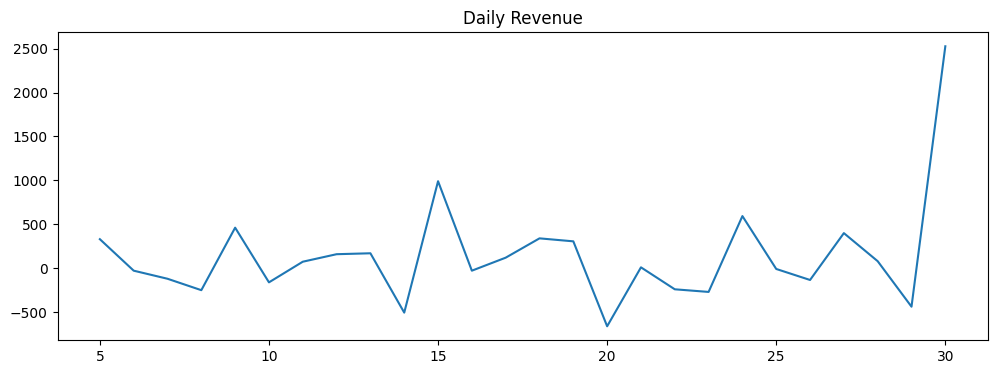

In [16]:
y_seasonal_diff.plot(figsize=(12,4), title="Daily Revenue")

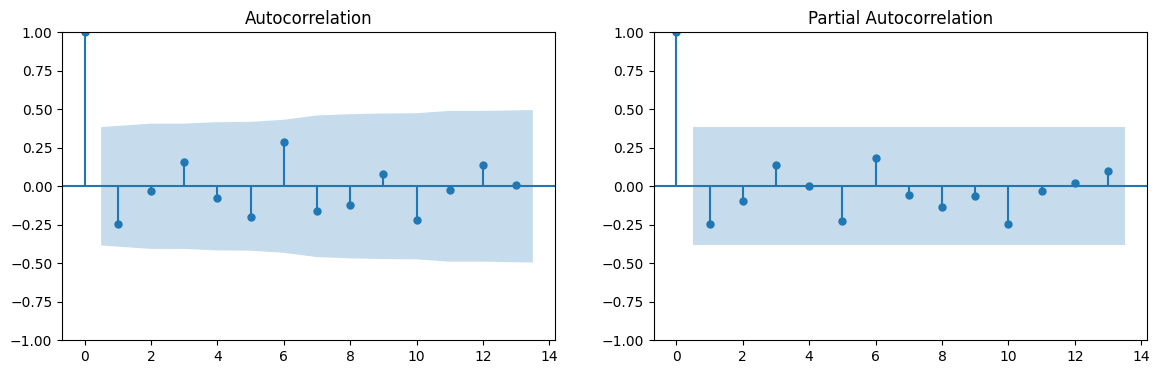

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,4))

plot_acf(y_seasonal_diff,  ax=axes[0])
plot_pacf(y_seasonal_diff,  ax=axes[1])

plt.show()


In [37]:
p=1
q=1
d=1

In [41]:
Q=1
P=1
D=1

In [42]:
s=5
order=(p,d,q)
seasonal_order=(P,D,Q,s)

In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()


In [44]:
print(results.summary())


                                     SARIMAX Results                                     
Dep. Variable:                     daily_revenue   No. Observations:                   31
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood                -141.552
Date:                           Tue, 03 Feb 2026   AIC                            293.105
Time:                                   16:37:50   BIC                            297.557
Sample:                                        0   HQIC                           293.719
                                            - 31                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4358      1.252     -0.348      0.728      -2.890       2.019
ma.L1         -0.9993      0.261     -3.832

forecast, evaluate forecast, rolling forecast origin, SARIMAX

In [45]:
n_steps = 14  # forecast horizon (e.g. 14 days)

forecast_res = results.get_forecast(steps=n_steps)
forecast_df = forecast_res.summary_frame()


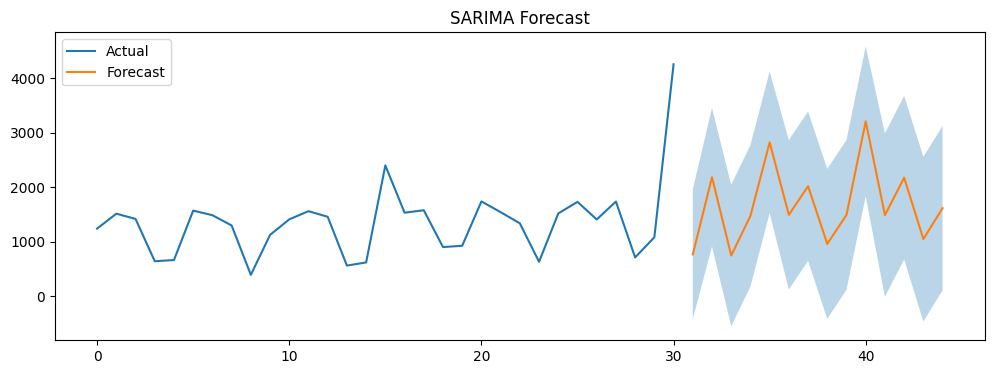

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y, label="Actual")
plt.plot(forecast_df["mean"], label="Forecast")
plt.fill_between(
    forecast_df.index,
    forecast_df["mean_ci_lower"],
    forecast_df["mean_ci_upper"],
    alpha=0.3
)
plt.legend()
plt.title("SARIMA Forecast")
plt.show()


In [64]:
# y.index = pd.to_datetime(y.index)

split_date = 20

y_train = y[y.index < split_date]
y_test  = y[y.index >= split_date]


In [63]:
y.index

RangeIndex(start=0, stop=31, step=1)

In [66]:
y_test

20    1737.96
21    1540.91
22    1335.99
23     629.85
24    1517.47
25    1729.42
26    1406.95
27    1735.49
28     709.73
29    1079.48
30    4255.88
Name: daily_revenue, dtype: float64

In [67]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,5),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [68]:
forecast_res = results.get_forecast(steps=len(y_test))
forecast_df = forecast_res.summary_frame()

y_pred = forecast_df["mean"]


In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE:  438.32
RMSE: 679.99


In [70]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"MAPE: {mape:.2f}%")


MAPE: 25.36%


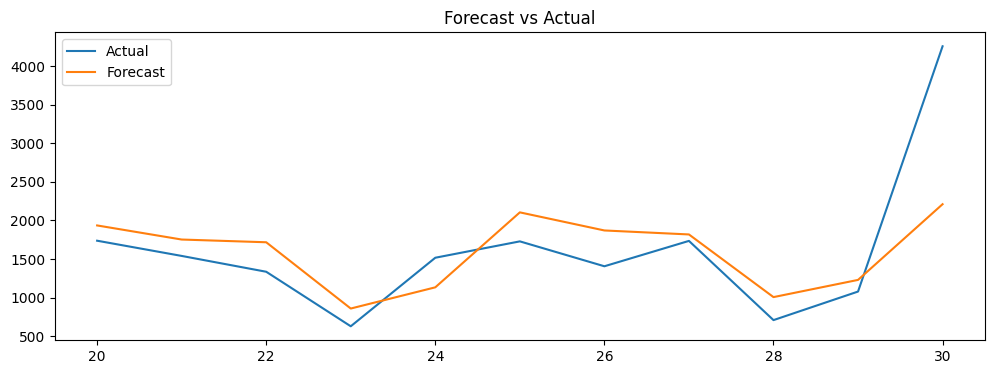

In [71]:
plt.figure(figsize=(12,4))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Forecast")
plt.legend()
plt.title("Forecast vs Actual")
plt.show()


## Rolling Forecast Origin

In [76]:
from sklearn.metrics import mean_absolute_error

horizon = 7      # forecast horizon
start = int(len(y) * 0.7)  # initial train size

errors = []

for i in range(start, len(y) - horizon):
    train = y.iloc[:i]
    test  = y.iloc[i:i+horizon]

    model = SARIMAX(
        train,
        order=(1,1,1),
        seasonal_order=(1,1,1,5),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    res = model.fit(disp=False)

    forecast = res.get_forecast(steps=horizon)
    pred = forecast.summary_frame()["mean"]

    errors.append(mean_absolute_error(test, pred))


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [77]:
print(f"Rolling MAE (h={horizon}): {np.mean(errors):.2f}")


Rolling MAE (h=7): 290.22
